In [28]:
#Package Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson
#import soccerdata as sd

In [7]:
allresults = pd.read_csv("results.csv")
start_date = "2018-01-01"

QUALIFIED_TEAMS_2026 = {
    # Host nations + Round of 16 (as of July 2026)
    "Canada", "Brazil", "Paraguay", "Morocco", "Norway", "France", "Mexico",
    "England", "Belgium", "United States", "Spain", "Portugal", "Switzerland",
    "Egypt", "Argentina", "Colombia",
    # Round of 32 (eliminated)
    "South Africa", "Japan", "Germany", "Netherlands", "Ivory Coast", "Sweden",
    "Ecuador", "DR Congo", "Senegal", "Bosnia and Herzegovina", "Austria",
    "Croatia", "Algeria", "Australia", "Cape Verde", "Ghana",
    # Group stage (eliminated)
    "Czech Republic", "South Korea", "Qatar", "Scotland", "Haiti", "Turkey",
    "Curaçao", "Tunisia", "New Zealand", "Iran", "Saudi Arabia", "Uruguay",
    "Iraq", "Jordan", "Uzbekistan", "Panama",
}

In [11]:
#Data Cleaning
worldcupdata = allresults[allresults['date'] >= start_date]
worldcupdata = worldcupdata[worldcupdata["home_score"].notna() & worldcupdata["away_score"].notna()]
worldcupdata["home_score"] = worldcupdata["home_score"].astype(int)
worldcupdata["away_score"] = worldcupdata["away_score"].astype(int)

In [13]:
worldcupdata.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
41297,2018-01-02,Iraq,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True
41298,2018-01-02,Oman,Bahrain,1,0,Gulf Cup,Kuwait City,Kuwait,True
41299,2018-01-05,Oman,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True
41300,2018-01-07,Estonia,Sweden,1,1,Friendly,Abu Dhabi,United Arab Emirates,True
41301,2018-01-11,Denmark,Sweden,0,1,Friendly,Abu Dhabi,United Arab Emirates,True


In [16]:
#Masking to ensure we are only looking at matches between qualified teams
mask = (
    worldcupdata["home_team"].isin(QUALIFIED_TEAMS_2026) |
    worldcupdata["away_team"].isin(QUALIFIED_TEAMS_2026)
)

worldcupdata = worldcupdata[mask]

In [17]:
worldcupdata.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
41297,2018-01-02,Iraq,United Arab Emirates,0,0,Gulf Cup,Kuwait City,Kuwait,True
41300,2018-01-07,Estonia,Sweden,1,1,Friendly,Abu Dhabi,United Arab Emirates,True
41301,2018-01-11,Denmark,Sweden,0,1,Friendly,Abu Dhabi,United Arab Emirates,True
41303,2018-01-11,Jordan,Finland,1,2,Friendly,Abu Dhabi,United Arab Emirates,True
41305,2018-01-27,Moldova,South Korea,0,1,Friendly,Antalya,Turkey,True


In [18]:
# =========================================================================
# Reshape to long format: one row per TEAM per match, rather than one row
# per match. This is the standard setup for the "double Poisson" model --
# each team's goal count becomes its own observation, with the team's own
# name as the "attack" effect and the opponent's name as the "defense"
# effect. is_home captures home-field advantage.
# =========================================================================
home_df = worldcupdata.rename(columns={
    "home_team": "team", "away_team": "opponent",
    "home_score": "goals", "away_score": "opponent_goals"
}).copy()
home_df["is_home"] = 1
 
away_df = worldcupdata.rename(columns={
    "away_team": "team", "home_team": "opponent",
    "away_score": "goals", "home_score": "opponent_goals"
}).copy()
away_df["is_home"] = 0
 
long_df = pd.concat([home_df, away_df], ignore_index=True)
long_df = long_df[["date", "team", "opponent", "goals", "opponent_goals", "is_home", "tournament"]]
 
print(f"Long-format dataset: {len(long_df)} team-match observations")
long_df.head()

Long-format dataset: 7636 team-match observations


,date,team,opponent,goals,opponent_goals,is_home,tournament
0,2018-01-02,Iraq,United Arab Emirates,0,0,1,Gulf Cup
1,2018-01-07,Estonia,Sweden,1,1,1,Friendly
2,2018-01-11,Denmark,Sweden,0,1,1,Friendly
3,2018-01-11,Jordan,Finland,1,2,1,Friendly
4,2018-01-27,Moldova,South Korea,0,1,1,Friendly


In [26]:
# =========================================================================
# Fit the Poisson GLM.
# Model: goals ~ team (attack strength) + opponent (defense strength, i.e.
#        how many goals teams tend to concede against this opponent)
#        + is_home (home advantage)
#
# lambda_i = exp( alpha_team_i - beta_opponent_i + gamma * is_home_i )
# where alpha, beta, gamma are the fitted coefficients (in log-scale).
# =========================================================================
poisson_model = smf.glm(
    formula="goals ~ team + opponent + is_home",
    data=long_df,
    family=sm.families.Poisson()
).fit()
 
print(poisson_model.summary())
 

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  goals   No. Observations:                 7636
Model:                            GLM   Df Residuals:                     7222
Model Family:                 Poisson   Df Model:                          413
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10235.
Date:                Sun, 05 Jul 2026   Deviance:                       7820.4
Time:                        23:07:18   Pearson chi2:                 7.07e+03
No. Iterations:                    24   Pseudo R-squ. (CS):             0.4442
Covariance Type:            nonrobust                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [29]:
def predict_match(home_team, away_team, model, max_goals=10):
    lambda_home = model.predict(pd.DataFrame({
        "team": [home_team], "opponent": [away_team], "is_home": [1]
    })).iloc[0]
    lambda_away = model.predict(pd.DataFrame({
        "team": [away_team], "opponent": [home_team], "is_home": [0]
    })).iloc[0]
 
    home_probs = poisson.pmf(np.arange(0, max_goals + 1), lambda_home)
    away_probs = poisson.pmf(np.arange(0, max_goals + 1), lambda_away)
    score_matrix = np.outer(home_probs, away_probs)  # rows=home goals, cols=away goals
 
    p_home_win = np.tril(score_matrix, -1).sum()  # home goals > away goals
    p_draw = np.trace(score_matrix)               # home goals == away goals
    p_away_win = np.triu(score_matrix, 1).sum()   # home goals < away goals
 
    return {
        "home_team": home_team, "away_team": away_team,
        "lambda_home": lambda_home, "lambda_away": lambda_away,
        "p_home_win": p_home_win, "p_draw": p_draw, "p_away_win": p_away_win,
        "score_matrix": score_matrix,
    }
 
 
# Example usage:
result = predict_match("Argentina", "France", poisson_model)
print(f"\n{result['home_team']} vs {result['away_team']}")
print(f"Expected goals: {result['lambda_home']:.2f} - {result['lambda_away']:.2f}")
print(f"P(home win): {result['p_home_win']:.3f}")
print(f"P(draw):     {result['p_draw']:.3f}")
print(f"P(away win): {result['p_away_win']:.3f}")


Argentina vs France
Expected goals: 1.39 - 0.97
P(home win): 0.466
P(draw):     0.272
P(away win): 0.262


AttributeError: 'numpy.ndarray' object has no attribute 'values'

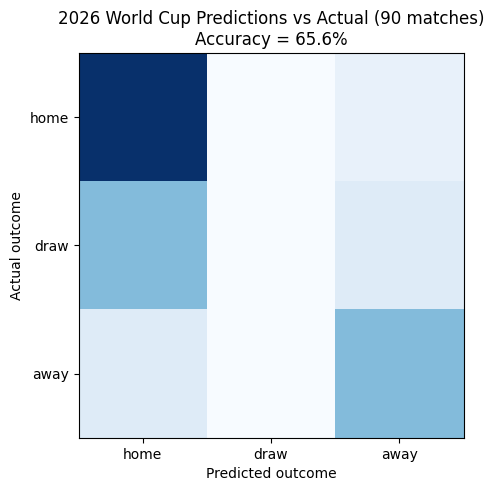

In [32]:
df = pd.read_csv("results.csv")
df["date"] = pd.to_datetime(df["date"])

TOURNAMENT_START = "2026-06-11"
train = df[df["date"] < TOURNAMENT_START].copy()
test = df[(df["tournament"] == "FIFA World Cup") & (df["date"] >= TOURNAMENT_START)].copy()

def to_long(data):
    home_df = data.rename(columns={
        "home_team": "team", "away_team": "opponent",
        "home_score": "goals", "away_score": "opponent_goals"
    }).copy()
    home_df["is_home"] = 1
    away_df = data.rename(columns={
        "away_team": "team", "home_team": "opponent",
        "away_score": "goals", "home_score": "opponent_goals"
    }).copy()
    away_df["is_home"] = 0
    return pd.concat([home_df, away_df], ignore_index=True)

train = train[train["home_score"].notna() & train["away_score"].notna()].copy()
test = test[test["home_score"].notna() & test["away_score"].notna()].copy()

train = train[
    train["home_team"].isin(QUALIFIED_TEAMS_2026) &
    train["away_team"].isin(QUALIFIED_TEAMS_2026)
].copy()

model = smf.glm(
    formula="goals ~ team + opponent + is_home",
    data=to_long(train),
    family=sm.families.Poisson()
).fit()

def predict_match(home_team, away_team, model, max_goals=10):
    lam_h = model.predict(pd.DataFrame({"team":[home_team],"opponent":[away_team],"is_home":[1]})).iloc[0]
    lam_a = model.predict(pd.DataFrame({"team":[away_team],"opponent":[home_team],"is_home":[0]})).iloc[0]
    hp = poisson.pmf(np.arange(0, max_goals+1), lam_h)
    ap = poisson.pmf(np.arange(0, max_goals+1), lam_a)
    mat = np.outer(hp, ap)
    return {"p_home": np.tril(mat,-1).sum(), "p_draw": np.trace(mat), "p_away": np.triu(mat,1).sum()}

# Predict every actual match and compare to real outcome
results = []
for _, row in test.iterrows():
    pred = predict_match(row["home_team"], row["away_team"], model)
    actual = ("home" if row["home_score"] > row["away_score"]
              else "away" if row["away_score"] > row["home_score"] else "draw")
    predicted = max([("home",pred["p_home"]),("draw",pred["p_draw"]),("away",pred["p_away"])], key=lambda x: x[1])[0]
    results.append({"actual": actual, "predicted": predicted})

res_df = pd.DataFrame(results)
accuracy = (res_df["actual"] == res_df["predicted"]).mean()

# Confusion matrix
labels = ["home", "draw", "away"]
conf = pd.crosstab(res_df["actual"], res_df["predicted"]).reindex(index=labels, columns=labels, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf.values, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted outcome")
ax.set_ylabel("Actual outcome")
ax.set_title(f"2026 World Cup Predictions vs Actual ({len(res_df)} matches)\nAccuracy = {accuracy:.1%}")
for i in range(3):
    for j in range(3):
        ax.text(j, i, conf.values[i,j], ha="center", va="center",
                 color="white" if conf.values[i,j] > conf.values.values.max()/2 else "black", fontsize=14)
plt.tight_layout()
plt.savefig("wc2026_confusion_matrix.png", dpi=150)
plt.show()

print(f"Accuracy: {accuracy:.1%}")